<a href="https://colab.research.google.com/github/jonabaroadsrp/dsrp/blob/main/Lab2_Muestreo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSRP
## Curso de Estadística Inferencial con Python
#### Prof. Ernesto Ponsot (Ph.D.)
Última actualización: 15-3-2024

# Laboratorio 2. Muestreo
El objetivo de este laboratorio es repasar las distribuciones derivadas de la normal, el teorema del límite central y realizar ejercicios de muestreo en Python.


## Actividad 1
### Distribuciones derivadas de la normal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def dibuja(df, tit="Distribución"):
  plt.figure(figsize=(8,4))
  plt.plot(df.x, df.c, color="Blue")
  plt.plot(df.x, df.nc, color="Red")
  plt.legend(["Central", "No central"])
  plt.xlim([df.x.min(), df.x.max()])
  plt.ylim([0, df.c.max()+0.1])
  plt.ylabel('f(x)', fontsize=12)
  plt.xlabel('x', fontsize=12)
  plt.title(tit)
  return plt

### $\chi^2$

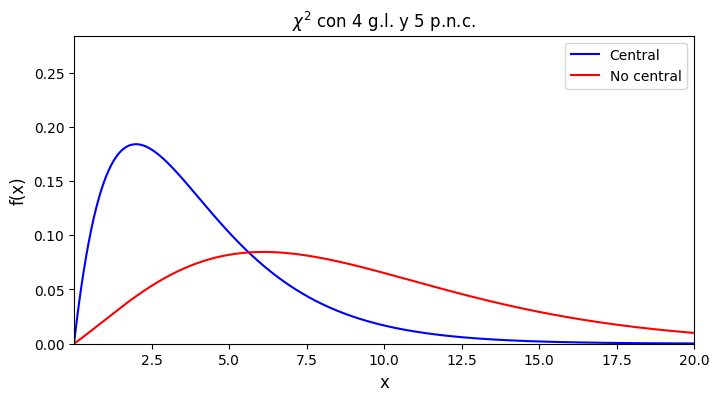

In [2]:
from scipy.stats import chi2
from scipy.stats import ncx2

v = 4 # Grados de libertad
nc = 5 # Parámetro de no centralidad

df = pd.DataFrame({'x': np.linspace(0.001, 20, 1000)})
df['c'] = chi2.pdf(df.x, v)
df['nc'] = ncx2.pdf(df.x, v, nc)

plt = dibuja(df, r"$\chi^2$ con "+str(v)+ " g.l. y " + str(nc) + " p.n.c.")
plt.show()

### $F$


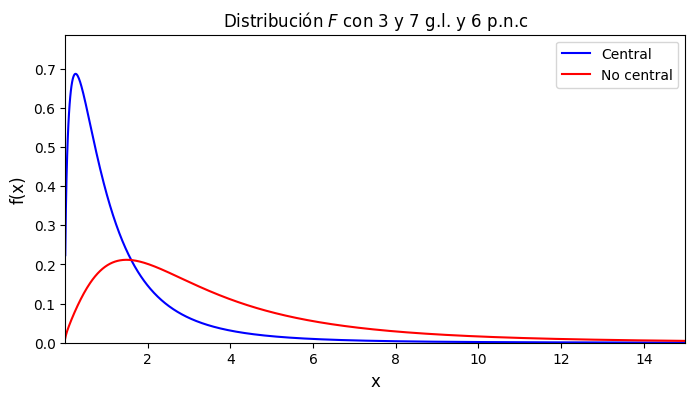

In [3]:
from scipy.stats import f
from scipy.stats import ncf

v1 = 3 # Grados de libertad de numerador
v2 = 7 # Grados de libertad de denominador
nc = 6 # Parámetro de no centralidad

df = pd.DataFrame({'x': np.linspace(0.01, 15, 1000)})
df['c'] = f.pdf(df.x, v1, v2)
df['nc'] = ncf.pdf(df.x, v1, v2, nc)

plt = dibuja(df, r"Distribución $F$ con "+str(v1)+" y "+str(v2)+
           " g.l. y "+str(nc)+" p.n.c")
plt.show()

### $t$-Student

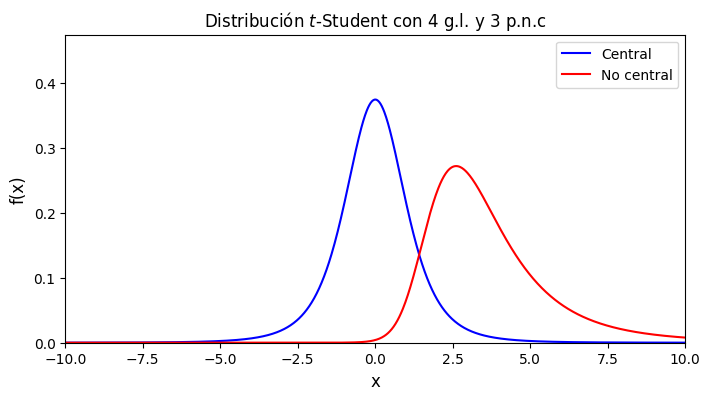

In [4]:
from scipy.stats import t
from scipy.stats import nct

v = 4 # Grados de libertad
nc = 3 # Parámetro de no centralidad

df = pd.DataFrame({'x': np.linspace(-10, 10, 1000)})
df['c'] = t.pdf(df.x, v)
df['nc'] = nct.pdf(df.x, v, nc)

plt = dibuja(df, r"Distribución $t$-Student con "+str(v)+ " g.l. y "+
             str(nc)+" p.n.c")
plt.show()

## Actividad 2
### Teorema del límite central (TLC)

Esta actividad ilustra la validez del TLC mediante las herramientas conocidas hasta el momento en el curso.

+ Suponga que tomamos $n$ muestras de una población de Poisson (por ejemplo, del número de llegadas de clientes a un banco en un día cualquiera) con tasa $\lambda=10$ por día.
+ Suponga que estimamos la media de la población (de hecho, $\lambda$) mediante el cálculo de la media muestral.
+ Suponga que podemos repetir el experimento $m$ veces, de forma independiente cada vez.

El objetivo es producir alguna ilustración del funcionamiento del TLC para el promedio, a medida que variamos el tamaño muestral.

<Figure size 800x600 with 0 Axes>

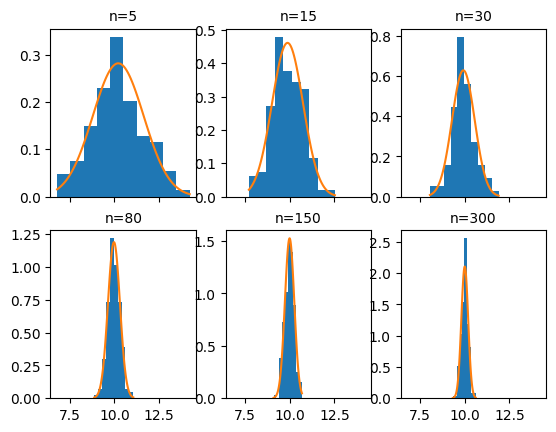

In [5]:
import numpy as np
from scipy.stats import poisson
from scipy.stats import norm

np.random.seed(seed=2000)

lamb = 10 # Tasa de llegadas
m = 200 # Número de experimentos
prom = np.zeros(m)
tm = [5, 15, 30, 80, 150, 300] # Distintos tamaños muestrales a probar

plt.figure(figsize=(8,6))
fig, ax = plt.subplots(2, 3, sharex=True)

i, j = 0, 0
for n in tm:
  for k in range(m):
    x = poisson.rvs(lamb, size=n)
    prom[k] = x.mean()
  med = prom.mean()
  des = np.sqrt(prom.var())
  val_x = np.linspace(prom.min(), prom.max(), 100)
  val_y = norm.pdf(val_x, med, des)

  ax[i,j].hist(prom, density=True)
  ax[i,j].plot(val_x, val_y)
  ax[i,j].set_title("n="+str(n), size=10)
  #ax.set_xticks([])

  j += 1
  if j>2:
    i += 1
    j = 0

plt.show()


### Actividad 3. Tamaños de muestra

#### Para la media

In [ ]:
def tm_media(d, s2, N=None, a=0.05):
  """
  d: Error máximo admisible
  s2: Varianza poblacional
  N: Tamaño de la población
  a: Nivel de significación (alpha)
  """
  import numpy as np
  from scipy.stats import norm

  z = norm.ppf(1-a/2)
  n0 = d**2/(z**2 * s2)
  if N is None:
    return int(np.round(1/n0, 0))
  else:
    return int(np.round(1/(n0+1/N), 0))

def tm_prop(d, p=0.5, N=None, a=0.05):
  """
  d: Error máximo admisible
  p: Probabilidad de éxito en la población
  N: Tamaño de la población
  a: Nivel de significación (alpha)
  """
  z = norm.ppf(1-a/2)
  n0 = d**2/(z**2 * p * (1-p))
  if N is None:
    return int(np.round(1/n0, 0))
  else:
    return int(np.round(1/((N-1)*n0/N+1/N), 0))

In [ ]:
n_med = tm_media(0.5, 16)
print(n_med)
n_med = tm_media(0.5, 16, a=0.01)
print(n_med)

n_prop = tm_prop(0.1)
print(n_prop)
n_prop = tm_prop(0.1, p=0.7)
print(n_prop)


246
425
96
81


#### Ejemplo.

Suponga que tenemos una población de 10000 empresas en la que el ingreso anual se distribuye normal con media 120000 dólares y desviación estándar 20000 dólares. Suponga que sólo un 30% de ellas pagan impuestos. Encontremos el tamaño de la muestra para estimar la media poblacional con un error máximo admisible de 3000 dólares y la proporción poblacional de las empresas que pagan impuestos con un error máximo admisible de 0.08.

In [ ]:
from scipy.stats import norm
from scipy.stats import bernoulli as ber

np.random.seed(seed=1000)

N = 10000 # Tamaño de la población

pob = pd.DataFrame({"ingresos": norm.rvs(120000, 20000, size=N).astype(int),
                    "pago_imp": ber.rvs(0.3, size=N)})
pob

,ingresos,pago_imp
0,103910,1
1,126418,1
2,119490,0
3,132886,0
4,113984,0
...,...,...
9995,95747,0
9996,117478,0
9997,118713,1
9998,130114,1


#### La muestra piloto

Ahora, suponiendo que tenemos la población, calculemos los parámetros poblacionales...


In [ ]:
med = pob.ingresos.mean()
var = pob.ingresos.var(ddof=0)
de = np.sqrt(var)
prop = pob.pago_imp.mean()

print("La media de la población: ", med)
print("La varianza de la población: ", var)
print("La D.E. de la población: ", de)
print("La proporción de la población: ", prop)


La media de la población:  119762.0927
La varianza de la población:  407032493.6003096
La D.E. de la población:  20175.046309743866
La proporción de la población:  0.2934


y tomemos una muestra piloto de tamaño 15

In [ ]:
m_piloto = pob.sample(15)
m_piloto

,ingresos,pago_imp
7639,120732,1
8998,105601,0
6602,106258,0
8532,130288,1
9803,140985,0
5778,154702,1
7729,151352,0
1625,122841,0
3761,108225,0
4345,139466,1


Los parámetros de la muestra piloto

In [ ]:
# La media del ingreso
med_p = m_piloto.ingresos.mean()
# La desviación estándar del ingreso
de_p = m_piloto.ingresos.std()
# La proporción de quienes pagan impuestos
prop_p = m_piloto.pago_imp.mean()

print("La media de la muestra piloto: ", med_p)
print("La D.E. de la muestra piloto: ", de_p)
print("La proporción de la muestra piloto: ", prop_p)

La media de la muestra piloto:  123245.93333333333
La D.E. de la muestra piloto:  17713.453899978587
La proporción de la muestra piloto:  0.3333333333333333


#### Cálculo del tamaño muestral

Ahora, con las estimaciones dadas, calculemos los tamaños muestrales definitivos

In [ ]:
n_media = tm_media(3000, de_p**2, N)
n_prop = tm_prop(0.05, p=prop_p, N=N)
print("Tamaño muestral para la media: ", n_media)
print("Tamaño muestral para la proporción: ", n_prop)

Tamaño muestral para la media:  132
Tamaño muestral para la proporción:  330


#### La muestra

En este ejercicio deseamos estimar tanto la media como la proporción poblacional, por consiguiente, debemos seleccionar el tamaño muestral que sea mayor entre los dos. Entonces:

In [ ]:
n=np.max([n_media, n_prop])
print("Tamaño muestral definitivo:", n)

Tamaño muestral definitivo: 330


Tomemos la muestra aleatoria simple...

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
muestra = pob.sample(n)
muestra.reset_index(names=["id"], inplace=True)
#muestra.to_csv("/content/drive/MyDrive/Colab Notebooks/DSRP/Programa de especialización en Ciencia de Datos/Estadística inferencial/emp_sri.csv",
#               sep=";")
muestra

,id,ingresos,pago_imp
0,3232,85395,0
1,1831,119351,1
2,6748,82136,0
3,7340,108296,0
4,6301,144879,0
...,...,...,...
325,1181,161968,0
326,492,117687,0
327,929,114911,0
328,8345,110816,0


Por último, las estimaciones...

In [ ]:
media_est = muestra.ingresos.mean()
de_est = muestra.ingresos.std()
prop_est = muestra.pago_imp.mean()

print("La media estimada: ", np.round(media_est,2), ". Valor en la población: ",
      np.round(med, 2), ". Error absoluto:", np.round(np.abs(med-media_est),2))
print("La D.E. estimada: ", np.round(de_est,2), ". Valor en la población: ",
      np.round(de,2), ". Error absoluto:", np.round(np.abs(de-de_est),2))
print("La proporción estimada: ", np.round(prop_est,2), ". Valor en la población: ",
      np.round(prop,2), ". Error absoluto:", np.round(np.abs(prop-prop_est),2))

La media estimada:  118337.76 . Valor en la población:  119762.09 . Error absoluto: 1424.33
La D.E. estimada:  19892.97 . Valor en la población:  20175.05 . Error absoluto: 282.07
La proporción estimada:  0.26 . Valor en la población:  0.29 . Error absoluto: 0.03


# 🧮 Tarea: Muestreo del ingreso usando una distribución χ²

## Enunciado

Repetir el ejercicio de muestreo sólo para el ingreso, pero ahora suponiendo una distribución  χ².  
Encuentre los grados de libertad apropiados, simule la población, extraiga muestras, calcule las medias muestrales y grafique su distribución.

## 1. Planteamiento y parámetros.

- Simularemos una población de ingresos que sigue una distribución χ² (chi-cuadrado).
- Usamos grados de libertad `k=10` (la media teórica será 10, ajústalo si necesitas otro valor).
- Población simulada de 10,000 individuos.*texto en cursiva*

## 2. Código de simulación y muestreo.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
k = 10  # Grados de libertad (puedes ajustar según la media real de ingresos)
tam_poblacion = 10000

# Simulación de la población de ingresos
np.random.seed(123)
poblacion_ingresos = np.random.chisquare(df=k, size=tam_poblacion)

# Muestreo aleatorio repetido
n_muestras = 500
tam_muestra = 25
medias_muestrales = []

for _ in range(n_muestras):
    muestra = np.random.choice(poblacion_ingresos, size=tam_muestra, replace=False)
    medias_muestrales.append(np.mean(muestra))

# Estadísticos de las medias muestrales
media_media = np.mean(medias_muestrales)
desv_media = np.std(medias_muestrales, ddof=1)

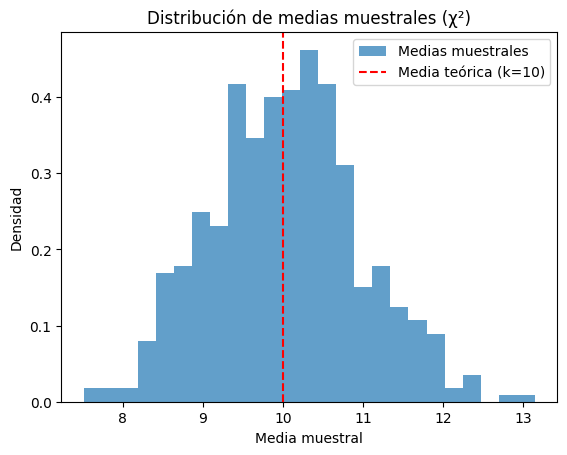

Media de las medias muestrales: 10.04
Desviación estándar de las medias muestrales: 0.92
Media teórica de χ²: 10
Varianza teórica de χ²: 20


In [7]:
plt.hist(medias_muestrales, bins=25, density=True, alpha=0.7, label="Medias muestrales")
plt.axvline(x=k, color='red', linestyle='--', label=f"Media teórica (k={k})")
plt.title("Distribución de medias muestrales (χ²)")
plt.xlabel("Media muestral")
plt.ylabel("Densidad")
plt.legend()
plt.show()

print(f"Media de las medias muestrales: {media_media:.2f}")
print(f"Desviación estándar de las medias muestrales: {desv_media:.2f}")
print(f"Media teórica de χ²: {k}")
print(f"Varianza teórica de χ²: {2*k}")

## 4. Explicación y reflexión.

La variable "ingreso" simulada como χ²(k) tiene media teórica igual a los grados de libertad (k=10).

La distribución de las medias muestrales se centra en torno a ese valor, mostrando el efecto del Teorema del Límite Central.

Aunque la χ² es asimétrica, la distribución de las medias muestrales tiende a la normalidad al aumentar el número de muestras.

Puedes repetir el experimento variando el tamaño muestral o los grados de libertad para explorar más a fondo el comportamiento.